# Modern ML Baselines: Prophet and XGBoost

**Outline**
1. Load data
2. Prophet — multiplicative seasonality, US holidays, cross-validation, component plots
3. XGBoost — lag/calendar feature engineering, early stopping, SHAP importances
4. Metrics: RMSE, MAE, MAPE
5. Side-by-side forecast plot and export

---

## Step 0: Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os
import logging
import warnings
warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)  # suppress per-fold Stan logs

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

import xgboost as xgb
import shap

from sklearn.metrics import mean_absolute_error

os.makedirs('../outputs/figures', exist_ok=True)

Importing plotly failed. Interactive plots will not work.


## Step 1: Load Data

In [2]:
train = pd.read_csv('../data/daily_train.csv', index_col='datetime', parse_dates=True)
test  = pd.read_csv('../data/daily_test.csv',  index_col='datetime', parse_dates=True)

train_series = train['power']
test_series  = test['power']

print(f"Train: {train_series.index.min().date()} → {train_series.index.max().date()} ({len(train_series)} obs)")
print(f"Test:  {test_series.index.min().date()}  → {test_series.index.max().date()} ({len(test_series)} obs)")

Train: 2006-12-16 → 2009-11-30 (1081 obs)
Test:  2009-12-01  → 2010-11-26 (361 obs)


## Step 2: Prophet

### 2.1 Fit

Multiplicative seasonality is appropriate for the same reason as ETS — winter variance scales with the series level rather than being a fixed additive offset. French public holidays are added as a structural regressor using Prophet's built-in country calendar, which is appropriate given the dataset covers a French household.

In [3]:
# Prophet requires columns named ds (date) and y (target)
prophet_train = train_series.reset_index().rename(columns={'datetime': 'ds', 'power': 'y'})

model_prophet = Prophet(
    seasonality_mode='multiplicative',
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    uncertainty_samples=500,
    interval_width=0.95
)
model_prophet.add_country_holidays(country_name='FR')
model_prophet.fit(prophet_train)

23:28:01 - cmdstanpy - INFO - Chain [1] start processing


23:28:01 - cmdstanpy - INFO - Chain [1] done processing


### 2.2 Cross-Validation

Prophet's built-in cross-validation is a methodological advantage worth noting: it performs a proper walk-forward evaluation by fitting the model on progressively larger training windows and scoring each horizon independently. This is more informative than a single train/test split because it shows how error accumulates as the forecast horizon extends.

In [4]:
df_cv = cross_validation(
    model_prophet,
    initial='366 days',   # minimum training window for each fold
    period='30 days',     # how often to advance the cutoff
    horizon='30 days',   # forecast window evaluated per fold — capped by training length
    parallel='threads',
)

df_perf = performance_metrics(df_cv)
print(df_perf[['horizon', 'rmse', 'mae', 'mape']].to_string(index=False))

23:28:01 - cmdstanpy - INFO - Chain [1] start processing


23:28:01 - cmdstanpy - INFO - Chain [1] start processing


23:28:01 - cmdstanpy - INFO - Chain [1] start processing


23:28:01 - cmdstanpy - INFO - Chain [1] start processing


23:28:01 - cmdstanpy - INFO - Chain [1] start processing


...

23:28:03 - cmdstanpy - INFO - Chain [1] start processing


23:28:03 - cmdstanpy - INFO - Chain [1] start processing


23:28:03 - cmdstanpy - INFO - Chain [1] done processing


23:28:03 - cmdstanpy - INFO - Chain [1] done processing


horizon     rmse      mae     mape
 3 days 0.271079 0.193572 0.255823
 4 days 0.274356 0.189237 0.231720
 5 days 0.291652 0.208022 0.245978
 6 days 0.273754 0.206579 0.253502
 7 days 0.273819 0.210941 0.274496
 8 days 0.276364 0.216387 0.290782
 9 days 0.296756 0.228378 0.333307
10 days 0.326352 0.250575 0.388232
11 days 0.319196 0.242220 0.370493
12 days 0.314076 0.246960 0.352729
13 days 0.314032 0.250719 0.336060
14 days 0.319252 0.254368 0.357951
15 days 0.303171 0.239027 0.356957
16 days 0.300466 0.234243 0.395968
17 days 0.315362 0.248144 0.447563
18 days 0.342557 0.278502 0.485131
19 days 0.358545 0.294362 0.481258
20 days 0.392698 0.306812 0.475604
21 days 0.390816 0.292736 0.469652
22 days 0.360203 0.263010 0.452140
23 days 0.333824 0.254140 0.447926
24 days 0.337722 0.246773 0.400313
25 days 0.338434 0.240776 0.345640
26 days 0.332888 0.235625 0.281995
27 days 0.326149 0.236697 0.259977
28 days 0.318822 0.241705 0.244336
29 days 0.323840 0.249270 0.263623
30 days 0.320196 0.2

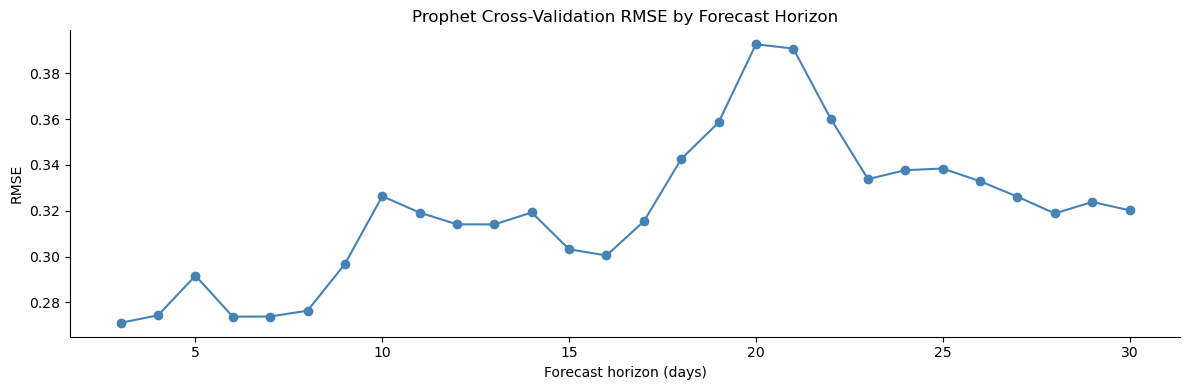

Saved → ../outputs/figures/prophet_cv_rmse.png


In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_perf['horizon'].dt.days, df_perf['rmse'], marker='o', linewidth=1.5, color='steelblue')
ax.set_xlabel('Forecast horizon (days)')
ax.set_ylabel('RMSE')
ax.set_title('Prophet Cross-Validation RMSE by Forecast Horizon')
sns.despine()
plt.tight_layout()
plt.savefig('../outputs/figures/prophet_cv_rmse.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → ../outputs/figures/prophet_cv_rmse.png")

### 2.3 Walk-Forward Forecast

`forecast_prophet` (the single-fit prediction over the full future) is retained for the component decomposition plot below. The walk-forward loop then refits Prophet at each fold on the expanding context so the evaluation uses the same strategy as every other model in the project.

In [6]:
# Single-fit forecast — used only for the component decomposition plot in the next cell
h = len(test_series)
future = model_prophet.make_future_dataframe(periods=h)
forecast_prophet = model_prophet.predict(future)

# Walk-forward evaluation — refit Prophet at each fold with expanding context
FOLD_SIZE   = 30
N_FOLDS     = 12
fold_starts = list(range(0, N_FOLDS * FOLD_SIZE, FOLD_SIZE))

prophet_preds_list = []
prophet_context    = train_series.copy()

for i, start in enumerate(fold_starts):
    end      = min(start + FOLD_SIZE, len(test_series))
    fold_len = end - start

    df_fold = prophet_context.reset_index().rename(columns={'datetime': 'ds', 'power': 'y'})
    m = Prophet(
        seasonality_mode='multiplicative',
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        uncertainty_samples=0,  # skip uncertainty to speed up each refit
    )
    m.add_country_holidays(country_name='FR')
    m.fit(df_fold)

    future_fold = m.make_future_dataframe(periods=fold_len)
    fc          = m.predict(future_fold)
    preds       = fc.set_index('ds')['yhat'].tail(fold_len)
    preds.index = test_series.index[start:end]
    prophet_preds_list.append(preds)

    prophet_context = pd.concat([prophet_context, test_series.iloc[start:end]])
    print(f"  Prophet fold {i+1}/{len(fold_starts)}: days {start+1}–{end}")

prophet_forecast = pd.concat(prophet_preds_list)
print(f"\nCompleted {len(fold_starts)} folds covering {len(prophet_forecast)} test days")

23:28:04 - cmdstanpy - INFO - Chain [1] start processing


23:28:04 - cmdstanpy - INFO - Chain [1] done processing


23:28:04 - cmdstanpy - INFO - Chain [1] start processing


  Prophet fold 1/12: days 1–30


23:28:04 - cmdstanpy - INFO - Chain [1] done processing


...

23:28:07 - cmdstanpy - INFO - Chain [1] done processing


23:28:07 - cmdstanpy - INFO - Chain [1] start processing


  Prophet fold 11/12: days 301–330


23:28:07 - cmdstanpy - INFO - Chain [1] done processing


  Prophet fold 12/12: days 331–360

Completed 12 folds covering 360 test days


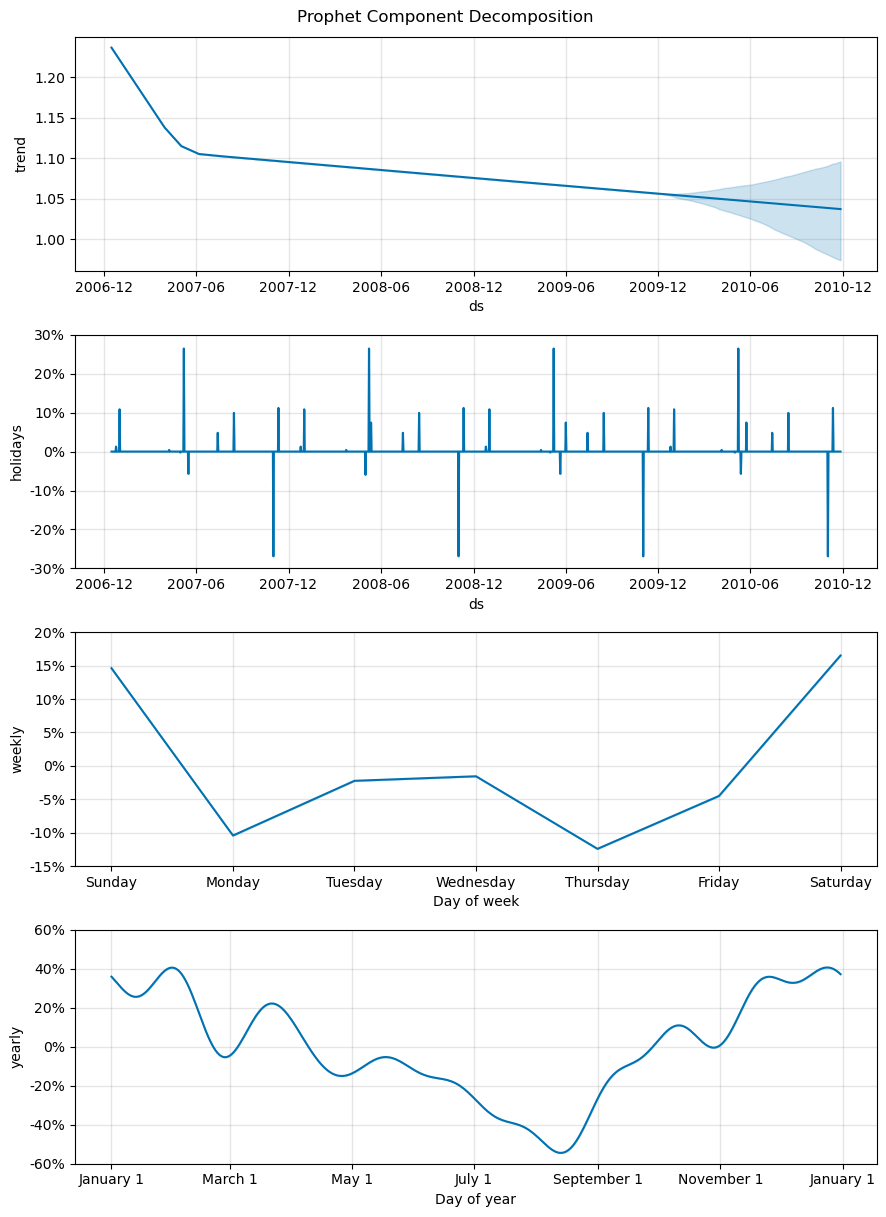

Saved → ../outputs/figures/prophet_components.png


In [7]:
fig_comp = model_prophet.plot_components(forecast_prophet)
fig_comp.suptitle('Prophet Component Decomposition', y=1.01)
fig_comp.savefig('../outputs/figures/prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → ../outputs/figures/prophet_components.png")

## Step 3: XGBoost

### 3.1 Feature Engineering

Tree models have no native concept of temporal order — XGBoost cannot learn that yesterday's power consumption predicts today's the way an ARIMA term does. The feature matrix below reconstructs that temporal structure explicitly.

**Data leakage guard:** Every rolling statistic uses `.shift(1)` before the window calculation. Without the shift, the rolling mean at time *t* would include the value at time *t* itself, meaning the model would see the target it is trying to predict as part of its own features. The shift ensures each feature uses only information available *before* the current observation.

**Sub-metering lags** give XGBoost a multivariate signal: yesterday's and last-week's kitchen, laundry, and heating consumption are informative predictors of total power that the univariate lag features alone cannot capture.

**Calendar encoding:** `month` and other calendar features are left as integers. This is appropriate for tree models, which split on thresholds rather than treating feature values as magnitudes — integer encoding introduces no ordinal bias the way it would in a linear model. The one limitation is that December (12) and January (1) appear numerically distant despite being adjacent; `day_of_year` provides an overlapping seasonal signal that partially compensates.

In [8]:
def make_features(df):
    # retain only the columns used for feature engineering — prevents contemporaneous
    # measurements (voltage, current, reactive_power) from leaking into the feature matrix
    df = df[['power', 'sub_meter_kitchen', 'sub_meter_laundry', 'sub_meter_heating']].copy()
    # lag features
    for lag in [1, 7, 14, 30]:
        df[f'lag_{lag}'] = df['power'].shift(lag)
    # rolling statistics — .shift(1) prevents the current day's value from leaking into its own features
    df['rolling_mean_7']  = df['power'].shift(1).rolling(7).mean()
    df['rolling_mean_30'] = df['power'].shift(1).rolling(30).mean()
    df['rolling_std_7']   = df['power'].shift(1).rolling(7).std()
    # calendar features
    df['day_of_week']  = df.index.dayofweek
    df['month']        = df.index.month
    df['day_of_year']  = df.index.dayofyear
    df['is_weekend']   = (df.index.dayofweek >= 5).astype(int)
    # sub-metering lag features
    for col in ['sub_meter_kitchen', 'sub_meter_laundry', 'sub_meter_heating']:
        df[f'{col}_lag_1'] = df[col].shift(1)
        df[f'{col}_lag_7'] = df[col].shift(7)
        df.drop(columns=col, inplace=True)  # drop the unshifted column — it's contemporaneous
    return df.dropna()

In [9]:
# Build features on the full series so test-set lags can reach back into training history.
# Note: lag features for test days use actual observed values, not predictions — appropriate
# for batch evaluation but not real-time deployment (which would require recursive forecasting).
full = pd.concat([train, test])
full_featured = make_features(full)

feature_cols = [c for c in full_featured.columns if c != 'power']

featured_train = full_featured.loc[train.index.intersection(full_featured.index)]
featured_test  = full_featured.loc[test.index.intersection(full_featured.index)]

print(f"Feature matrix: {len(feature_cols)} features")
print(f"Train rows: {len(featured_train)}  |  Test rows: {len(featured_test)}")
featured_train[feature_cols].head(3)

Feature matrix: 17 features
Train rows: 1051  |  Test rows: 361


,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_30,rolling_std_7,day_of_week,month,day_of_year,is_weekend,sub_meter_kitchen_lag_1,sub_meter_kitchen_lag_7,sub_meter_laundry_lag_1,sub_meter_laundry_lag_7,sub_meter_heating_lag_1,sub_meter_heating_lag_7
datetime,,,,,,,,,,,,,,,,,
2007-01-15,2.090992,1.556500,1.909031,3.053475,1.605114,1.762853,0.421153,0,1,15,0,1777.0,0.0,4215.0,467.0,12991.5,17547.0
2007-01-16,1.492137,1.297954,0.881414,2.354486,1.595919,1.710808,0.423089,1,1,16,0,1099.0,1688.0,2239.0,4267.0,15163.0,9790.0
2007-01-17,1.171114,1.496389,0.704204,1.530435,1.577799,1.671363,0.440342,2,1,17,0,2063.0,771.0,644.0,4456.0,6583.0,11012.0


### 3.2 Train / Validation Split

The validation set is the last 180 days of the training window — half a year provides a seasonally representative signal for early stopping without meaningfully starving the fit.

**Note on effective training start:** The official training window begins 2006-12-16, but lag feature construction (`lag_30` being the longest lag) introduces NaN rows that are dropped by `make_features`. The XGBoost fit window therefore starts on 2007-01-15 — approximately 30 days later than the documented training start and ~30 fewer observations than ETS, SARIMA, and Prophet.

In [10]:
val_cutoff = featured_train.index.max() - pd.Timedelta(days=180)

fit_df  = featured_train[featured_train.index <= val_cutoff]
val_df  = featured_train[featured_train.index >  val_cutoff]

X_fit,  y_fit  = fit_df[feature_cols],  fit_df['power']
X_val,  y_val  = val_df[feature_cols],  val_df['power']
X_test, y_test = featured_test[feature_cols], featured_test['power']

print(f"Fit window:  {fit_df.index.min().date()} → {fit_df.index.max().date()} ({len(fit_df)} obs)")
print(f"Val window:  {val_df.index.min().date()} → {val_df.index.max().date()} ({len(val_df)} obs)")
print(f"Test window: {featured_test.index.min().date()} → {featured_test.index.max().date()} ({len(featured_test)} obs)")

Fit window:  2007-01-15 → 2009-06-03 (871 obs)
Val window:  2009-06-04 → 2009-11-30 (180 obs)
Test window: 2009-12-01 → 2010-11-26 (361 obs)


### 3.3 Fit with Early Stopping

In [11]:
model_xgb = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    eval_metric='rmse',
    random_state=42,
    verbosity=0,
)

model_xgb.fit(
    X_fit, y_fit,
    eval_set=[(X_val, y_val)],
    verbose=100,
)

print(f"\nBest iteration: {model_xgb.best_iteration}")
print(f"Best val RMSE:  {model_xgb.best_score:.4f}")

[0]	validation_0-rmse:0.36922


[100]	validation_0-rmse:0.21314


[138]	validation_0-rmse:0.21306



Best iteration: 88
Best val RMSE:  0.2124


### 3.4 SHAP Feature Importances

SHAP (SHapley Additive exPlanations) values measure each feature's contribution to the model's output across all training observations. Unlike XGBoost's built-in gain metric, SHAP values are directional and additive — the summary plot shows both magnitude (x-axis) and whether high feature values push the prediction up or down (color).

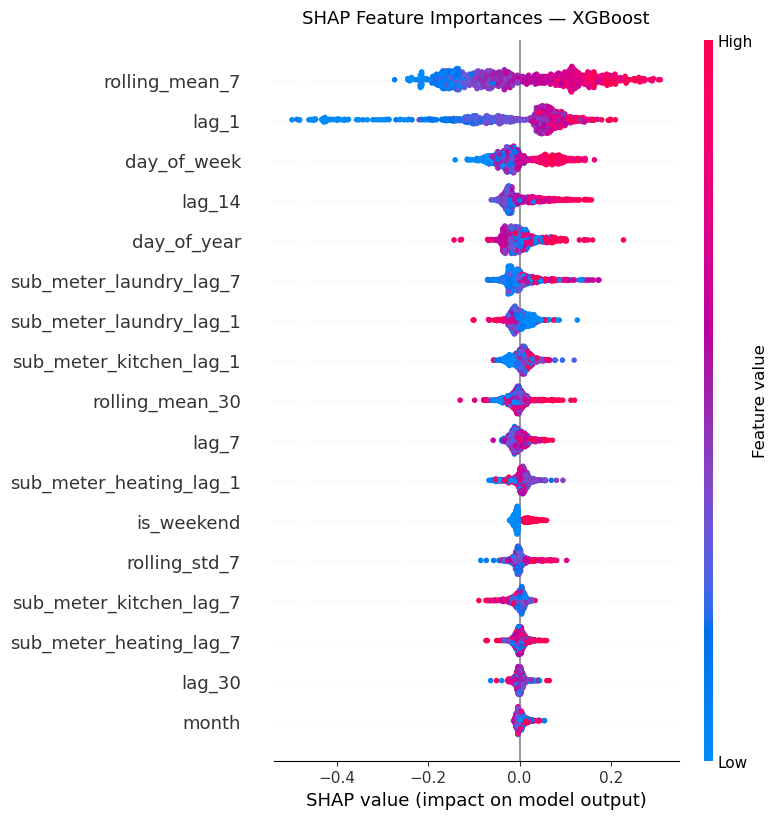

Saved → ../outputs/figures/xgboost_shap_importance.png


In [12]:
explainer   = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_fit)

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_values, X_fit, plot_type='dot', show=False, max_display=20)
plt.title('SHAP Feature Importances — XGBoost', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('../outputs/figures/xgboost_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → ../outputs/figures/xgboost_shap_importance.png")

### 3.5 XGBoost Forecast

XGBoost is evaluated in batch mode: lag features for test days use actual observed values rather than recursive predictions. This means `lag_1` on day 5 of testing is the true observed day 4, not a model-generated value. The approach is appropriate for retrospective benchmarking on a fixed dataset but would not be feasible in a live deployment, where future actuals are unavailable and recursive forecasting would be required.

In [13]:
xgb_preds = model_xgb.predict(X_test)
xgb_forecast = pd.Series(xgb_preds, index=y_test.index)

## Step 4: Metrics

In [14]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.array(y_true) - np.array(y_pred)) ** 2))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

fold_rows = []
for i, start in enumerate(fold_starts):
    end     = min(start + FOLD_SIZE, len(test_series))
    idx     = test_series.index[start:end]
    act     = test_series.loc[idx]
    xgb_idx = idx.intersection(xgb_forecast.index)  # XGBoost may drop early rows due to lag NaNs
    fold_rows.append({
        'Fold':          i + 1,
        'Prophet RMSE':  rmse(act, prophet_forecast.loc[idx]),
        'Prophet MAE':   mean_absolute_error(act, prophet_forecast.loc[idx]),
        'Prophet MAPE':  mape(act, prophet_forecast.loc[idx]),
        'XGBoost RMSE':  rmse(test_series.loc[xgb_idx], xgb_forecast.loc[xgb_idx]),
        'XGBoost MAE':   mean_absolute_error(test_series.loc[xgb_idx], xgb_forecast.loc[xgb_idx]),
        'XGBoost MAPE':  mape(test_series.loc[xgb_idx], xgb_forecast.loc[xgb_idx]),
    })

fold_df = pd.DataFrame(fold_rows).set_index('Fold').round(4)
display(fold_df)

metrics_modern = pd.DataFrame({
    'RMSE': [fold_df['Prophet RMSE'].mean(), fold_df['XGBoost RMSE'].mean()],
    'MAE':  [fold_df['Prophet MAE'].mean(),  fold_df['XGBoost MAE'].mean()],
    'MAPE': [fold_df['Prophet MAPE'].mean(), fold_df['XGBoost MAPE'].mean()],
}, index=['Prophet', 'XGBoost']).round(4)

print(f"\nMean across {len(fold_starts)} folds:")
print(metrics_modern.to_string())
metrics_modern.to_csv('../outputs/modern_ml_metrics.csv')
print("\nSaved → ../outputs/modern_ml_metrics.csv")

,Prophet RMSE,Prophet MAE,Prophet MAPE,XGBoost RMSE,XGBoost MAE,XGBoost MAPE
Fold,,,,,,
1,0.2664,0.1910,15.9493,0.2738,0.1911,14.7867
2,0.2934,0.2201,16.2547,0.2596,0.2185,16.2127
3,0.3350,0.2797,22.1268,0.3327,0.2618,23.2065
4,0.3175,0.2280,27.5894,0.3033,0.2307,25.0494
5,0.1905,0.1429,14.0662,0.1753,0.1325,14.1505
6,0.2194,0.1753,15.0024,0.1853,0.1457,12.8285
7,0.1855,0.1525,15.4291,0.1697,0.1340,15.2325
8,0.1934,0.1495,18.6441,0.1379,0.1079,14.7744
9,0.2540,0.1884,35.3478,0.2147,0.1794,37.6951



Mean across 12 folds:
           RMSE     MAE     MAPE
Prophet  0.2622  0.1986  20.6141
XGBoost  0.2395  0.1849  19.5994

Saved → ../outputs/modern_ml_metrics.csv


In [15]:
classical_path = '../outputs/classical_metrics.csv'

if os.path.exists(classical_path):
    metrics_classical = pd.read_csv(classical_path, index_col=0)
    leaderboard = pd.concat([metrics_classical, metrics_modern]).sort_values('RMSE')
    leaderboard.to_csv('../outputs/leaderboard.csv')
    print("Saved → ../outputs/leaderboard.csv")
else:
    leaderboard = metrics_modern.sort_values('RMSE')
    print("classical_metrics.csv not found — showing modern models only.")

display(
    leaderboard.style
    .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'MAPE': '{:.2f}%'})
    .background_gradient(cmap='RdYlGn_r', subset=['RMSE', 'MAE', 'MAPE'])
    .set_caption('Model Leaderboard — sorted by RMSE (lower is better)')
)

Saved → ../outputs/leaderboard.csv


,RMSE,MAE,MAPE
XGBoost,0.2395,0.1849,19.60%
SARIMA,0.2574,0.1956,21.29%
Prophet,0.2622,0.1986,20.61%
ETS,0.2996,0.2428,25.29%


## Step 5: Side-by-Side Forecast Plot

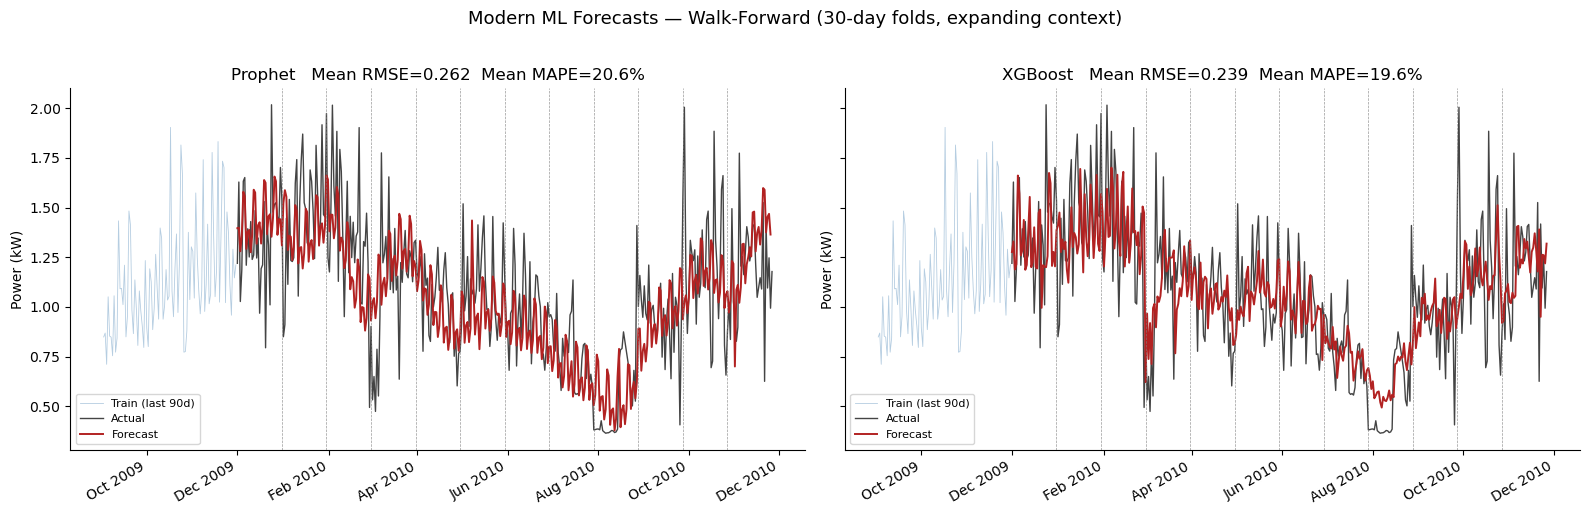

Saved → ../outputs/modern_ml_forecasts.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, (label, forecast) in zip(axes, [('Prophet', prophet_forecast), ('XGBoost', xgb_forecast)]):
    ax.plot(train_series.iloc[-90:], color='steelblue', linewidth=0.6, alpha=0.4, label='Train (last 90d)')
    ax.plot(test_series,             color='#444444',   linewidth=1.0, label='Actual')
    ax.plot(forecast,                color='firebrick', linewidth=1.4, label='Forecast')

    for s in fold_starts[1:]:
        ax.axvline(x=test_series.index[s], color='gray', linestyle='--', linewidth=0.5, alpha=0.8)

    rmse_val = metrics_modern.loc[label, 'RMSE']
    mape_val = metrics_modern.loc[label, 'MAPE']
    ax.set_title(f'{label}   Mean RMSE={rmse_val:.3f}  Mean MAPE={mape_val:.1f}%')
    ax.set_ylabel('Power (kW)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

plt.suptitle('Modern ML Forecasts — Walk-Forward (30-day folds, expanding context)', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/modern_ml_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → ../outputs/modern_ml_forecasts.png")